# Data Workflow: NYC Airbnb Listings

**Author:** Belal Nwiran

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) — pricing and listing characteristics for NYC Airbnb listings.

This project builds a complete, reproducible data workflow — loading, cleaning, exploring, and visualizing NYC Airbnb listing data — using Python, Pandas, and Matplotlib/Seaborn. The goal is to uncover patterns in pricing, availability, and listing characteristics across neighborhoods, while establishing clean, modular practices that later ML and agentic AI projects in this program will build on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AB_NYC_2019.csv", index_col='id')
df.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 15)

# Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 48895 entries, 2539 to 36487245
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  str    
 1   host_id                         48895 non-null  int64  
 2   host_name                       48874 non-null  str    
 3   neighbourhood_group             48895 non-null  str    
 4   neighbourhood                   48895 non-null  str    
 5   latitude                        48895 non-null  float64
 6   longitude                       48895 non-null  float64
 7   room_type                       48895 non-null  str    
 8   price                           48895 non-null  int64  
 9   minimum_nights                  48895 non-null  int64  
 10  number_of_reviews               48895 non-null  int64  
 11  last_review                     38843 non-null  str    
 12  reviews_per_month               38843 non-

In [5]:
df.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
def handle_missing_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fills missing 'reviews_per_month' values with 0.

    A missing 'reviews_per_month' corresponds to a listing with zero
    reviews. 'last_review' is left as NaN for
    these listings, since there is genuinely no review date to report.

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'reviews_per_month'.

    Returns
    -------
    pandas.DataFrame
        A new dataframe with 'reviews_per_month' NaNs filled with 0.
    """
    df = df.copy()
    affected = df['reviews_per_month'].isna().sum()
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    print(f"Filled reviews_per_month with 0 for {affected} listings.")
    return df

In [7]:
def handle_missing_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drops listings with missing 'name' or 'host_name'.

    These are identifying labels with no reasonable way to infer a
    missing value, and affect a negligible fraction of the dataset.
    Dropping is preferred over imputing a placeholder, since a
    placeholder would not represent real information.

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'name' and 'host_name'.

    Returns
    -------
    pandas.DataFrame
        A new dataframe with rows missing 'name' or 'host_name' removed.
    """
    df = df.copy()
    before = len(df)
    df = df.dropna(subset=['name', 'host_name'])
    dropped = before - len(df)
    
    print(f"Dropped {dropped} listings with missing name or host_name.")
    return df

In [8]:
def remove_invalid_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Removes listings with a price of 0.

    A price of 0 is not a valid nightly rate under any interpretation —
    unlike high-end prices (investigated separately and left in the
    dataset as legitimate), a $0 listing reflects a data entry error or
    an inactive/non-bookable listing. These rows are dropped rather than
    imputed, since there is no reliable way to infer the intended price.

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'price'.

    Returns
    -------
    pandas.DataFrame
        A new dataframe with price == 0 listings removed.
    """
    df = df.copy()
    before = len(df)
    df = df[df['price'] > 0]
    dropped = before - len(df)
    
    print(f"Dropped {dropped} listings with price == 0.")
    
    return df

In [9]:
def fix_data_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts columns to more appropriate data types.

    'last_review' is converted from string to datetime to enable
    time-based analysis. 'neighbourhood_group' and 'room_type' are
    converted to the 'category' dtype, since they take a small, fixed set
    of repeated string values — this reduces memory usage and better
    reflects their categorical nature for grouping and plotting.

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'last_review',
        'neighbourhood_group', and 'room_type'.

    Returns
    -------
    pandas.DataFrame
        A new dataframe with the specified columns converted.
    """
    df = df.copy()
    df['last_review'] = pd.to_datetime(df['last_review'])
    df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
    df['room_type'] = df['room_type'].astype('category')
    
    print("Converted 'last_review' to datetime; 'neighbourhood_group' and 'room_type' to category.")
    
    return df

In [10]:
cleaned_df = handle_missing_reviews(df)
cleaned_df = handle_missing_names(cleaned_df)
cleaned_df = remove_invalid_prices(cleaned_df)
cleaned_df = fix_data_types(cleaned_df)

Filled reviews_per_month with 0 for 10052 listings.
Dropped 37 listings with missing name or host_name.
Dropped 11 listings with price == 0.
Converted 'last_review' to datetime; 'neighbourhood_group' and 'room_type' to category.


# EDA

In [11]:
def price_summary_by_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarizes price by neighbourhood group and room type.

    Groups listings by 'neighbourhood_group' and 'room_type' and computes
    the mean, median, and count of 'price' within each group. Median is
    included alongside mean since price is right-skewed (a few very
    high-end listings can pull the mean up).

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'neighbourhood_group',
        'room_type', and 'price'.

    Returns
    -------
    pandas.DataFrame
        A dataframe indexed by (neighbourhood_group, room_type) with
        columns 'mean', 'median', and 'count'.
    """
    summary = (
        df.groupby(['neighbourhood_group', 'room_type'])['price']
        .agg(['mean', 'median', 'count'])
        .round(2)
    )
    return summary

In [12]:
def price_review_correlation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes correlation between price and review activity.

    Checks whether cheaper listings tend to have more reviews or more
    frequent reviews, using Pearson correlation across 'price',
    'number_of_reviews', and 'reviews_per_month'.

    Parameters
    ----------
    df : pandas.DataFrame
        The Airbnb listings dataframe, must contain 'price',
        'number_of_reviews', and 'reviews_per_month'.

    Returns
    -------
    pandas.DataFrame
        A correlation matrix for the three columns.
    """
    corr = df[['price', 'number_of_reviews', 'reviews_per_month']].corr().round(3)
    return corr

In [13]:
price_summary_by_group(cleaned_df)

mean  median  count
neighbourhood_group room_type                             
Bronx               Entire home/apt  127.65   100.0    378
                    Private room      66.89    54.0    651
                    Shared room       58.61    40.0     59
Brooklyn            Entire home/apt  178.38   145.0   9552
                    Private room      76.56    65.0  10117
                    Shared room       50.77    36.0    411
Manhattan           Entire home/apt  249.26   191.0  13189
                    Private room     116.81    90.0   7973
                    Shared room       88.98    69.0    480
Queens              Entire home/apt  147.05   120.0   2096
                    Private room      71.78    60.0   3370
                    Shared room       69.02    37.0    198
Staten Island       Entire home/apt  173.85   100.0    176
                    Private room      62.29    50.0    188
                    Shared room       57.44    30.0      9

In [14]:
price_review_correlation(cleaned_df)

,price,number_of_reviews,reviews_per_month
price,1.000,-0.048,-0.051
number_of_reviews,-0.048,1.000,0.589
reviews_per_month,-0.051,0.589,1.000


# Visualizations

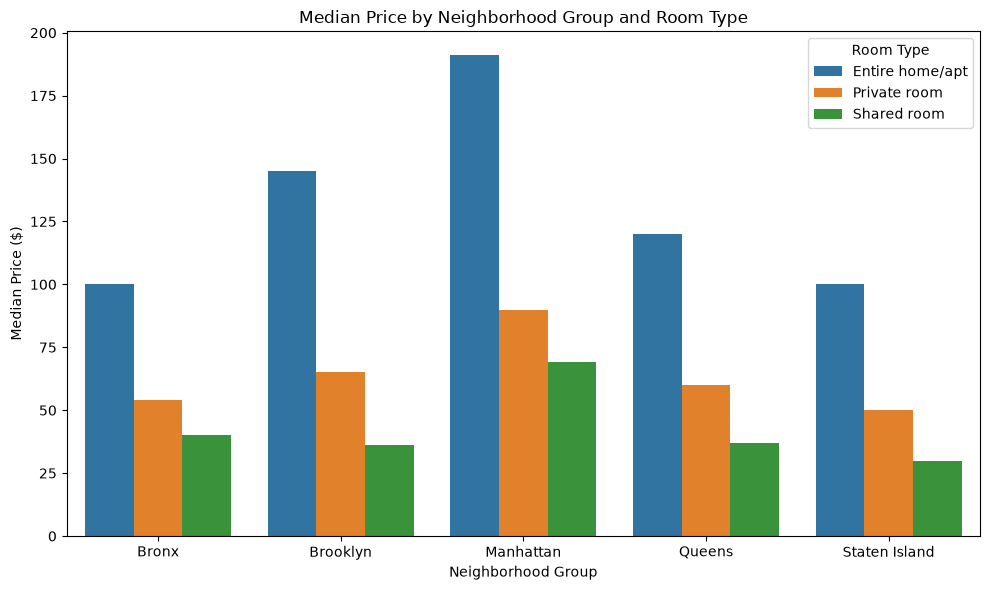

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cleaned_df,
    x='neighbourhood_group',
    y='price',
    hue='room_type',
    estimator='median',
    errorbar=None
)
plt.title('Median Price by Neighborhood Group and Room Type')
plt.xlabel('Neighborhood Group')
plt.ylabel('Median Price ($)')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

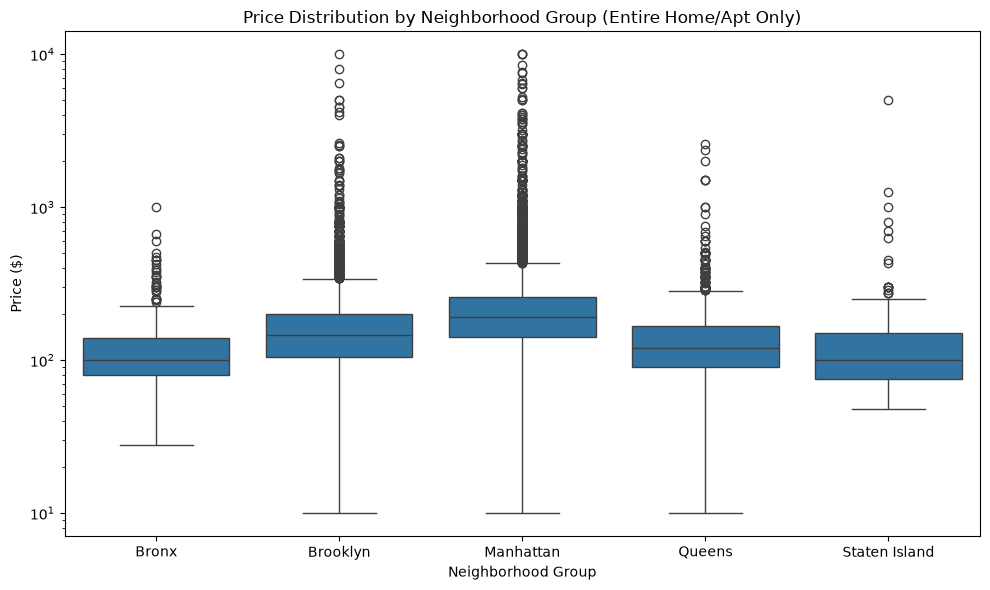

In [20]:
entire_home = cleaned_df[cleaned_df['room_type'] == 'Entire home/apt']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=entire_home,
    x='neighbourhood_group',
    y='price'
)
plt.yscale('log')
plt.title('Price Distribution by Neighborhood Group (Entire Home/Apt Only)')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

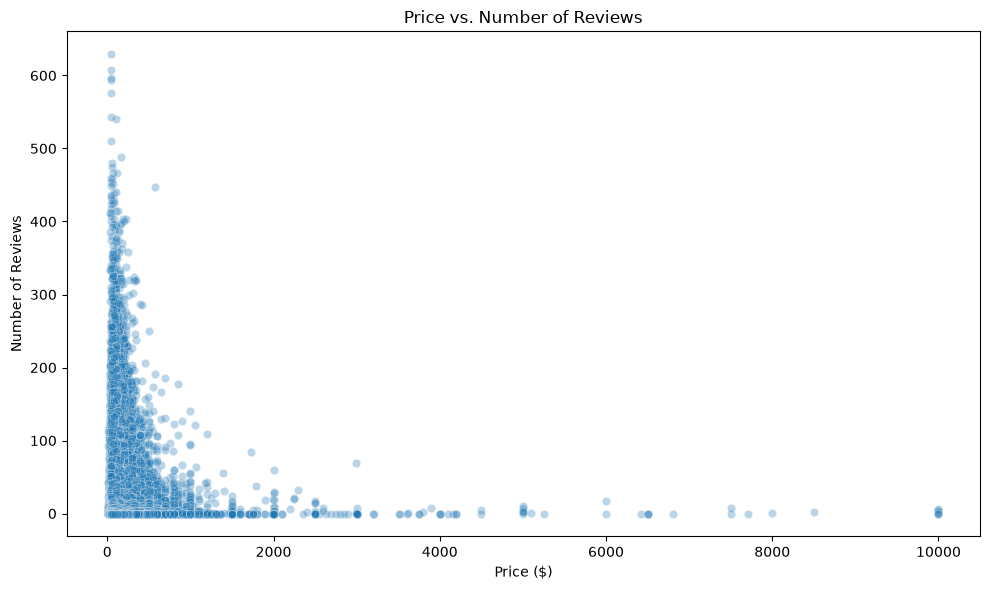

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cleaned_df,
    x='price',
    y='number_of_reviews',
    alpha=0.3
)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Price ($)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# Summary & Interpretation

This dataset has 48,895 NYC Airbnb listings from five boroughs. After cleaning — filling missing review data, removing listings with missing names or a price of 0, and fixing data types — 48,847 listings remained.

**Patterns and insights.** Price depends mostly on two things: borough and room type. Manhattan is the most expensive borough for every room type (median $191 for an entire home/apt). Brooklyn is next, then Staten Island and Queens (about equal), then the Bronx. Inside every borough, the order is the same: Entire home/apt costs more than Private room, and Private room costs more than Shared room. This pattern held in all five boroughs with no exceptions.

Price and number of reviews showed almost no relationship (r = -0.048 for number of reviews, r = -0.051 for reviews per month). The scatter plot showed this clearly: most reviews come from lower-priced listings. Listings above about $2,000 have almost no reviews at all. This suggests that review count does not tell us how "good" an expensive listing is — it more likely means expensive listings get booked, or reviewed, less often.

**Limitations and assumptions.** A few cleaning choices involved judgment calls. Missing `reviews_per_month` values were treated as zero reviews, since those same rows also had `number_of_reviews == 0`. Rows missing `name` or `host_name` (37 rows) were removed instead of filled in, since a placeholder value would not be real information, and these rows were a very small part of the data (about 0.08%). High prices (up to $10,000) and long `minimum_nights` values (up to 1,250) were kept in the data, since most are likely real listings and not errors. This is an assumption, not a confirmed fact, and it affects the summary statistics below.

**Surprising or unclear.** The boxplot for Entire home/apt prices showed something the summary table alone did not: Staten Island's mean price \\$173.85 is much higher than its median \\$100, even though Staten Island has the fewest listings (176) of the five boroughs. The boxplot explained why — one listing near \\$5,000 is enough to pull the mean well above the median in such a small group. This is a good reminder to check the full distribution, not just the mean, especially for smaller groups like Staten Island.